In [1]:
import os
import re
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm

import lightgbm

In [2]:
data = pd.read_csv('../input/jane-street-market-prediction/train.csv')

In [3]:
FEATURES = [f for f in data.columns if re.match('^feature_', f)]
AUC_TARGET = [f for f in data.columns if re.match('^rep_', f)]
DATE = 'date'
WEIGHT = 'weight'
TARGET = 'resp'

In [4]:
NAN = -9999

X = data.loc[data[WEIGHT] > 0.0][FEATURES].fillna(NAN).values
y = data.loc[data[WEIGHT] > 0.0][TARGET].values > 0.0

In [5]:
model = lightgbm.LGBMClassifier(learning_rate=0.05, n_estimators=150, reg_alpha=0.5, reg_lambda=2.0, subsample=0.8, colsample_bytree=0.6, num_leaves=35)
model.fit(X, y, eval_set=(X, y), eval_metric='auc')

[1]	training's auc: 0.52626	training's binary_logloss: 0.692904
[2]	training's auc: 0.53015	training's binary_logloss: 0.6927
[3]	training's auc: 0.530874	training's binary_logloss: 0.692522
[4]	training's auc: 0.533287	training's binary_logloss: 0.692343
[5]	training's auc: 0.534968	training's binary_logloss: 0.692172
[6]	training's auc: 0.536437	training's binary_logloss: 0.691989
[7]	training's auc: 0.536689	training's binary_logloss: 0.691841
[8]	training's auc: 0.537215	training's binary_logloss: 0.691692
[9]	training's auc: 0.537528	training's binary_logloss: 0.691557
[10]	training's auc: 0.538026	training's binary_logloss: 0.691433
[11]	training's auc: 0.53804	training's binary_logloss: 0.691289
[12]	training's auc: 0.538417	training's binary_logloss: 0.691178
[13]	training's auc: 0.538727	training's binary_logloss: 0.691073
[14]	training's auc: 0.539695	training's binary_logloss: 0.690965
[15]	training's auc: 0.53995	training's binary_logloss: 0.690851
[16]	training's auc: 0.54

LGBMClassifier(colsample_bytree=0.6, learning_rate=0.05, n_estimators=150,
               num_leaves=35, reg_alpha=0.5, reg_lambda=2.0, subsample=0.8)

# Plot

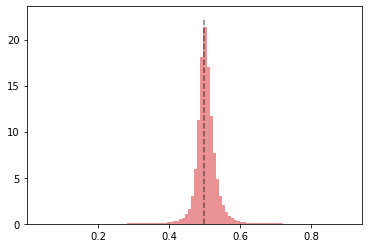

In [6]:
pred = model.predict_proba(X)[:, 1]
plt.hist(pred, 100, density=True, color='tab:red', alpha=0.5)
plt.vlines(0.5, *plt.ylim(), color='k', alpha=0.5, linestyle='--');

# Save

In [7]:
pickle.dump(model, open(os.path.join('../working', 'model.pkl'), 'wb'), protocol=pickle.HIGHEST_PROTOCOL)

# Submission

In [8]:
THR = 0.5

In [9]:
import janestreet
env = janestreet.make_env()
iter_test = env.iter_test()

for (test_df, sample_prediction_df) in tqdm(iter_test):
    sample_prediction_df.action = (model.predict_proba(test_df[FEATURES].fillna(NAN).values)[:, 1] > THR).astype(int)
    env.predict(sample_prediction_df)